In [1]:
# imports
from pyha_analyzer import extractors
from pyha_analyzer.preprocessors import MelSpectrogramPreprocessorsNew
import torch
from datetime import datetime


import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as torchmodels


from torchvision.utils import make_grid

from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

In [2]:
config = {
    "learning_rate": 10e-3,
    "learning_rate_decay": 0.001,
    "device": 'cuda',
    "latent_dim": 10,
    "percept": True
}

config["save_path"] = "model_dim_" + str(config["latent_dim"]) + ".pt"

In [3]:
# extract our data
coralreef_extractor = extractors.MultiCoralReef()
coral_ads = coralreef_extractor('/home/a.jajodia.229/acoustic/local_data/coral')


preprocessor = MelSpectrogramPreprocessorsNew(duration=5, class_list=coral_ads["train"].features["labels"].feature.names)



coral_ads["train"].set_transform(preprocessor)

min size is 15538 from dataset Paola
sampling 15538 from (Paola, 0)
sampling 15538 from (Paola, 1)
sampling 1294 from (Williams_et_al_2024, 0)
sampling 1294 from (Williams_et_al_2024, 1)
Loaded: 33664 samples


Casting the dataset:   0%|          | 0/23564 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3030 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/7070 [00:00<?, ? examples/s]

In [4]:
VGG = torchmodels.vgg16(weights=torchmodels.VGG16_Weights.DEFAULT).features[:13]
for nm, mod in VGG.named_modules():
    if isinstance(mod, nn.MaxPool2d):
        setattr(VGG, nm,  nn.AvgPool2d(2 ,2))
VGG.eval().to(config["device"])


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [5]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.shape = shape

    def forward(self, x):
        return x.reshape(x.shape[0], *self.shape)

In [6]:
# architecture from https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0283396
encoder = lambda nfeat : nn.Sequential(
    nn.Conv2d(1, 32, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    nn.Conv2d(32, 64, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.Conv2d(64, 128, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    nn.Conv2d(128, 256, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    nn.Conv2d(256, 512, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    nn.Conv2d(512, nfeat, 3, stride=2, padding=1),
    
    Reshape(nfeat * 4 * 4)
)

decoder = lambda nfeat : nn.Sequential(
    Reshape(nfeat, 4, 4),
    nn.ReLU(True),
    
    nn.Upsample(scale_factor=2),
    nn.Conv2d(nfeat, 512, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    nn.Conv2d(512, 512, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    
    nn.Upsample(scale_factor=2),
    nn.Conv2d(512, 256, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    nn.Conv2d(256, 256, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(256, 128, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    nn.Conv2d(128, 128, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(128, 64, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.Conv2d(64, 64, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(64, 32, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    nn.Conv2d(32, 32, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(32, 1, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(1),
    nn.ReLU(True),
    nn.Conv2d(1, 1, (3, 3), bias=False, padding=1)
)

In [7]:
encoder = encoder(config['latent_dim'])
decoder = decoder(config['latent_dim'])

model = nn.Sequential(
    encoder,
    decoder
).to(config['device'])

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0, lr=config["learning_rate"], betas=(0.8, 0.999))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch : (1-config["learning_rate_decay"])**epoch)
MSE = torch.nn.MSELoss()
train_loader = DataLoader(coral_ads['train'], batch_size=8, num_workers=8, shuffle=True, pin_memory=True, pin_memory_device=config['device'])

In [ ]:
step, loss = 0, []

for epoch in range(1):
    for data in tqdm(train_loader, desc=str(epoch), leave=False):

        x = data['audio']
        
        
        optimizer.zero_grad()
        label = x.to(config["device"])[..., :256]
        
        zeroes_index = (torch.sum(label, dim=0) != 0)
        
        
        x = encoder(label)
        
        pred = decoder(x)
        
        with torch.no_grad():
            pred[zeroes_index] = torch.zeroes_like(pred[zeroes_index])
        
            if config['percept'] == True:
                label_vgg = VGG(label.expand(label.shape[0], 3, *label.shape[2:]))
                pred_vgg = VGG(pred.expand(pred.shape[0], 3, *pred.shape[2:]))
                
                score = MSE(label_vgg, pred_vgg)
                

            else:
                score = MSE(label, pred)
            score.backward()
            optimizer.step()
            
            loss.append(score.item())
            # print(datetime.now())

        if len(loss) > 2000 and np.median(loss[-2000:-1000]) < np.median(loss[-1000:]):
            print('Early stop')
            torch.save(model.state_dict(), config["save_path"])
            break

        step += 1

        if step % 500 == 0: # scheduler
            scheduler.step()
            
        #     print(score)

        # Plot images
        if step % 250 == 0 :
            
            print(np.mean(loss[-250: step]))
            
            # Plot reconstructions
            label_images = [(e-e.min())/(e.max()-e.min()) for e in label[:8].detach().cpu().squeeze()]
            pred_images = [(e-e.min())/(e.max()-e.min()) for e in pred[:8].detach().cpu().squeeze()]
            
            images = np.array([label_images, pred_images])
            
            f, axarr = plt.subplots(2,8)
            plt.subplots_adjust(hspace=0)
            for i in range(2):
                for j in range(8):
                    axarr[i,j].imshow(images[i,j])
                    axarr[i,j].set_axis_off()
            plt.show()
            plt.close()

0:   0%|          | 0/2946 [00:00<?, ?it/s]

AttributeError: module 'torch' has no attribute 'zero_grad'

In [ ]:
torch.save(model.state_dict(), config["save_path"])

In [ ]:
model.load_state_dict(torch.load(config["save_path"]))
model.eval().to(config["device"])

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affin

In [ ]:
coral_ads['test'].set_transform(preprocessor)
test_loader = DataLoader(coral_ads['test'], batch_size=8, num_workers=12, shuffle=True, pin_memory=True, pin_memory_device=config['device'])


test_losses = []

test_embeddings = []


for data in tqdm(test_loader):
    x = data['audio']
    with torch.no_grad():
        label = x.to(config["device"])[..., :256]
        
        x = encoder(label)
        
        test_embeddings.append(x.detach().cpu())
        
        pred = decoder(x)


        score = MSE(label, pred)
    
        test_losses.append(score.item())

  0%|          | 0/884 [00:00<?, ?it/s]

Exception ignored from cffi callback <function SoundFile._init_virtual_io.<locals>.vio_read at 0x79f03bab4720>Exception ignored from cffi callback <function SoundFile._init_virtual_io.<locals>.vio_read at 0x79f03ba79300>:
:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/soundfile.py", line 1290, in vio_read
  File "/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/soundfile.py", line 1290, in vio_read
    @_ffi.callback("sf_vio_read")    
@_ffi.callback("sf_vio_read")
KeyboardInterrupt
: 
KeyboardInterrupt: 



KeyboardInterrupt: 

In [ ]:
np.array(test_losses).mean()

np.float64(0.035296724730984184)

In [ ]:
normalize = lambda e: (e-e.min())/(e.max()-e.min())

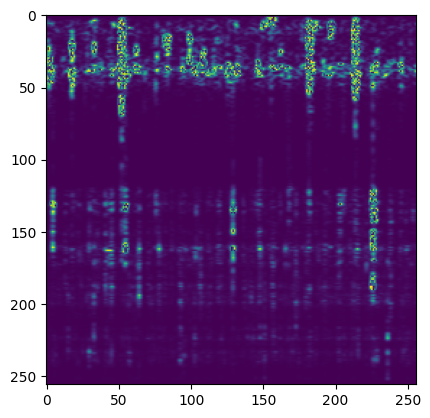

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(normalize(label[1]).detach().cpu().squeeze())

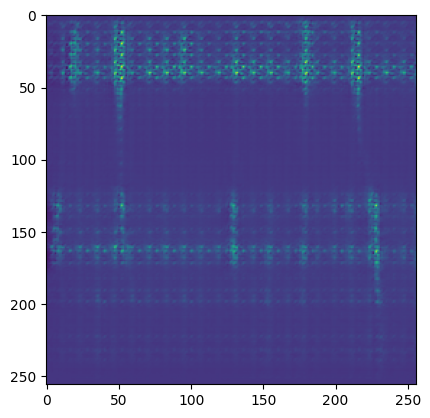

In [ ]:
plt.imshow(normalize(pred[1]).detach().cpu().squeeze())